Plotting of trajs

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---- 1. Set the project root folder ----
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)
    
from data_collection.data_utils import load_npz

# -----------------------------
# Load Data
# -----------------------------

# NN data
nn5_data = load_npz(
    "data/2026-02-26_12-23-53_TwoDofArm_NN_5_e38/2026-02-26_12-23-53_logs.npz"
)

# MPC datasets
mpc_data_5 = load_npz(
    "data/2026-02-25_15-03-55_TwoDofArm_N5/2026-02-25_15-03-55_logs.npz"
)

mpc_data_10 = load_npz(
    "data/2026-02-25_15-04-49_TwoDofArm_N10/2026-02-25_15-04-49_logs.npz"
)

mpc_data_50 = load_npz(
    "data/2026-02-25_15-24-50_TwoDofArm_N50/2026-02-25_15-24-50_logs.npz"
)

# -----------------------------
# Extract trajectories
# xyz_traj[..., 0] = x
# xyz_traj[..., 1] = y
# xyz_traj[..., 2] = z
# -----------------------------

mpc_traj_5 = mpc_data_5["default"]["xyz_traj"]
mpc_traj_10 = mpc_data_10["default"]["xyz_traj"]
mpc_traj_50 = mpc_data_50["default"]["xyz_traj"]
nn_traj_5 = nn5_data["default"]["xyz_traj"]

# Extract X and Z components
mpc_x_5 = mpc_traj_5[:, :, 0]
mpc_z_5 = mpc_traj_5[:, :, 2]

mpc_x_10 = mpc_traj_10[:, :, 0]
mpc_z_10 = mpc_traj_10[:, :, 2]

mpc_x_50 = mpc_traj_50[:, :, 0]
mpc_z_50 = mpc_traj_50[:, :, 2]

nn_x_5 = nn_traj_5[:, :, 0]
nn_z_5 = nn_traj_5[:, :, 2]

# -----------------------------
# Time + Horizon lengths
# -----------------------------

T = min(
    mpc_x_5.shape[0],
    mpc_x_10.shape[0],
    mpc_x_50.shape[0],
    nn_x_5.shape[0],
)

H_mpc_5 = mpc_x_5.shape[1] - 1
H_mpc_10 = mpc_x_10.shape[1] - 1
H_mpc_50 = mpc_x_50.shape[1] - 1
H_nn_5 = nn_x_5.shape[1] - 1

# -----------------------------
# Figure setup
# -----------------------------

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_title("MPC vs MPC + NN (X-Z Plane)")

ax.set_xlim(-0.8, 0.4)
ax.set_ylim(1.0, 2.0)

ax.set_aspect("equal", adjustable="box")
ax.grid(True)

# -----------------------------
# Start and Goal points (X-Z)
# -----------------------------

x0 = [0.3079166867244125, 0.0, 1.4171682076907781]
yref = [-0.5522350408628973, 0.0, 1.2858399579259427]

# Extract X and Z
x0_x, x0_z = x0[0], x0[2]
goal_x, goal_z = yref[0], yref[2]

# Plot start
ax.scatter(
    x0_x, x0_z,
    color="black",
    s=120,
    marker="o",
    label="Start"
)

# Plot goal
ax.scatter(
    goal_x, goal_z,
    color="gold",
    edgecolor="black",
    s=150,
    marker="*",
    label="Goal"
)

# Lines
mpc_line_5, = ax.plot([], [], color='purple', marker='.', lw=2,
                      markersize=3, label=f"MPC 5 (H={H_mpc_5})", alpha=0.3)

mpc_line_10, = ax.plot([], [], color='blue', marker='.', lw=2,
                       markersize=3, label=f"MPC 10 (H={H_mpc_10})", alpha=0.3)

mpc_line_50, = ax.plot([], [], color='green', marker='.', lw=2,
                       markersize=3, label=f"MPC 50 (H={H_mpc_50})", alpha=0.3)

nn_line_5, = ax.plot([], [], color='red', marker='.', lw=2,
                     markersize=3, label=f"NN 5 (H={H_nn_5})", alpha=0.3)

# Current points
mpc_point_5, = ax.plot([], [], color='purple', markersize=10, marker='s')
mpc_point_10, = ax.plot([], [], color='blue', markersize=10, marker='p')
mpc_point_50, = ax.plot([], [], color='green', markersize=10, marker='^')
nn_point_5, = ax.plot([], [], color='red', markersize=10, marker='d')

ax.legend()

# -----------------------------
# Animation update
# -----------------------------

def update(t):

    # MPC 5
    mpc_line_5.set_data(mpc_x_5[t], mpc_z_5[t])
    mpc_point_5.set_data([mpc_x_5[t, 0]], [mpc_z_5[t, 0]])

    # MPC 10
    mpc_line_10.set_data(mpc_x_10[t], mpc_z_10[t])
    mpc_point_10.set_data([mpc_x_10[t, 0]], [mpc_z_10[t, 0]])

    # MPC 50
    mpc_line_50.set_data(mpc_x_50[t], mpc_z_50[t])
    mpc_point_50.set_data([mpc_x_50[t, 0]], [mpc_z_50[t, 0]])

    # NN 5
    nn_line_5.set_data(nn_x_5[t], nn_z_5[t])
    nn_point_5.set_data([nn_x_5[t, 0]], [nn_z_5[t, 0]])

    return (
        mpc_line_5, mpc_point_5,
        mpc_line_10, mpc_point_10,
        mpc_line_50, mpc_point_50,
        nn_line_5, nn_point_5
    )

# -----------------------------
# Run animation
# -----------------------------

ani = FuncAnimation(fig, update, frames=T, interval=60, blit=True)

ani.save("xz_plane_animation.mp4", writer="ffmpeg", fps=30, dpi=300)

print("Animation saved as xz_plane_animation.mp4")

Current working directory: /home/nsoh/Documents/mpc_MuJoCo

Loaded file: data/2026-04-19_17-22-10_TwoDofArm_H2_NN/2026-04-19_17-22-10_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj', 'yref_q', 'xyzpos', 'GT_xyz_traj']


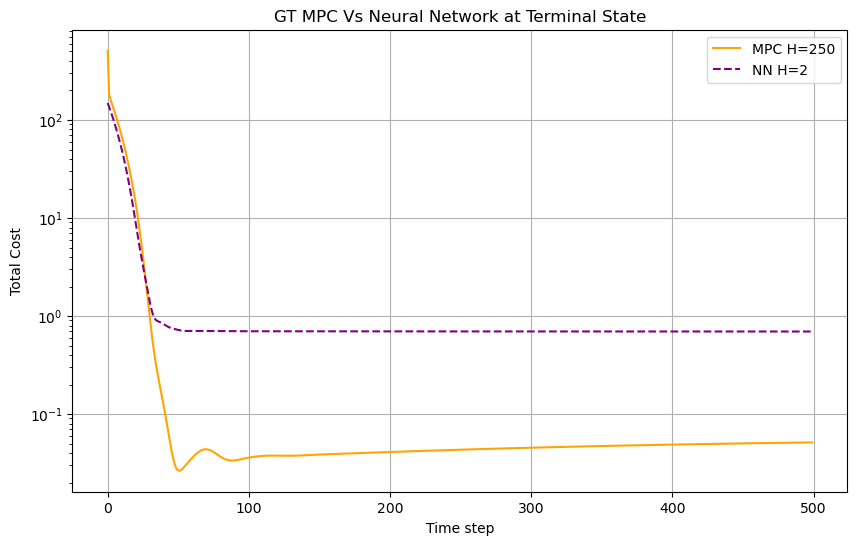

In [2]:
import os
import sys
import numpy as np

# ---- 1. Set the project root folder ----
# Adjust this to the path of your main project folder
project_root = "/home/nsoh/Documents/mpc_MuJoCo"  # e.g., "/Users/you/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Plot cost graph over time
import matplotlib.pyplot as plt
from data_collection.data_utils import load_npz

# Load NN data
nn2_data = load_npz("data/2026-04-19_17-22-10_TwoDofArm_H2_NN/2026-04-19_17-22-10_logs.npz")

# Extract total_cost arrays
nn2_cost = nn2_data["default"]["terminal_cost"]
GT_mpc_cost = nn2_data["default"]["GT_cost"]

# Create a time vector for each (assume uniform 1 step per time step)
t_GT_mpc = np.arange(len(GT_mpc_cost))
t_nn2 = np.arange(len(nn2_cost))

# Plot
plt.figure(figsize=(10, 6))

plt.plot(t_GT_mpc, GT_mpc_cost, label="MPC H=250", color="orange")
plt.plot(t_nn2, nn2_cost, label="NN H=2", linestyle="--", color="purple")

plt.xlabel("Time step")
plt.ylabel("Total Cost")
plt.yscale("log")
plt.title("GT MPC Vs Neural Network at Terminal State")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot absolute error between NN H=2 and MPC H=100
import numpy as np
import matplotlib.pyplot as plt
from data_collection.data_utils import load_npz

# Load NN data
nn2_data = load_npz("data/2026-02-25_15-29-43_TwoDofArm_NN_5_e60/2026-02-25_15-29-43_logs.npz")
GT_mpc_cost = nn2_data["default"]["GT_cost"]
nn2_cost = nn2_data["default"]["total_cost"]

# Make sure the arrays are the same length (truncate to the shorter one)
T = min(len(nn2_cost), len(GT_mpc_cost))
abs_error = np.abs(nn2_cost[:T] - GT_mpc_cost[:T])

# Time vector
t = np.arange(T)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, abs_error, color="red", label="|NN H=2 - MPC H=100|")

plt.xlabel("Time step")
plt.ylabel("Absolute Error")
plt.yscale("log")
plt.title("Absolute Error between NN H=2 and MPC H=100")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
  yref:
  - -0.5522350408628973
  - 0.0
  - 1.2858399579259427

  yref_q:
  - 0.24
  - -1.21
  - 0.0
  - 0.0

In [16]:
# Evaluate the NN at the set point.
import torch
import numpy as np
from neural_network.models import TwoDofArmModel

# -----------------------------
# Load model
# -----------------------------
weights_path = "value_iteration/output/2026-02-22_15-19-00_TwoDofArm_VI/loop_60/training/model_epoch_16.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TwoDofArmModel(None)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

# -----------------------------
# Define inputs
# -----------------------------

# Cartesian target
yref = np.array([
    -0.5522350408628973,
    0.0,
    1.2858399579259427
], dtype=np.float32)

# Joint reference
yref_q = np.array([
    0.24,
    -1.21,
    0.0,
    0.0
], dtype=np.float32)

# Concatenate
input_vec = np.concatenate([yref_q, yref])   # shape (7,)

# Convert to torch tensor with batch dimension
input_tensor = torch.tensor(input_vec, dtype=torch.float32).unsqueeze(0).to(device)

# -----------------------------
# Evaluate model
# -----------------------------

with torch.no_grad():
    output = model(input_tensor)

print("Input:", input_vec)
print("Model output:", output.cpu().numpy())

Input: [ 0.24       -1.21        0.          0.         -0.55223507  0.
  1.2858399 ]
Model output: [[0.4491743]]


Model loaded on: cpu


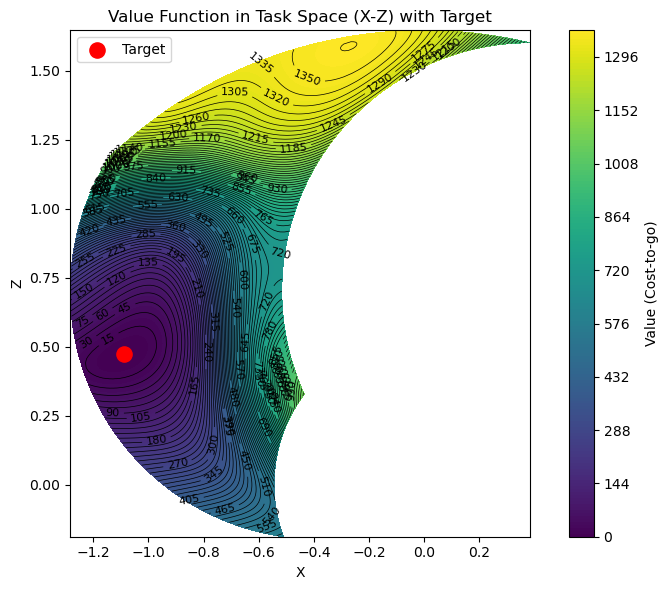

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# ---- 1. Set project root ----
project_root = "/home/nsoh/Documents/mpc_MuJoCo"
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection

def draw_capsule(ax, p1, p2, radius, color='red', alpha=0.4):
    """
    Draw a 2D capsule between p1 and p2 with given radius.
    """
    p1 = np.array(p1)
    p2 = np.array(p2)

    # მიმართულება (direction)
    d = p2 - p1
    length = np.linalg.norm(d)

    if length == 0:
        # Degenerate → just a circle
        circle = Circle(p1, radius, color=color, alpha=alpha)
        ax.add_patch(circle)
        return

    d_unit = d / length

    # perpendicular vector
    perp = np.array([-d_unit[1], d_unit[0]])

    # ოთხი კუთხე rectangle-ისთვის
    corner1 = p1 + radius * perp
    corner2 = p1 - radius * perp
    corner3 = p2 - radius * perp
    corner4 = p2 + radius * perp

    # rectangle (middle part)
    polygon = plt.Polygon([corner1, corner2, corner3, corner4],
                          color=color, alpha=alpha)
    ax.add_patch(polygon)

    # end circles
    circle1 = Circle(p1, radius, color=color, alpha=alpha)
    circle2 = Circle(p2, radius, color=color, alpha=alpha)

    ax.add_patch(circle1)
    ax.add_patch(circle2)
    
from neural_network.models import TwoDofArmModel

# ============================================================
# 1. Load Model
# ============================================================
weights_path = "value_iteration/output/2026-04-28_15-10-27_TwoDofArm_VI/loop_1/training/model_epoch_15.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TwoDofArmModel(None)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()
print("Model loaded on:", device)

# ============================================================
# 2. Target (from YAML)
# ============================================================
yref = np.array([
  -1.0880862442477446,
  0.0,
  0.47330858112333174
], dtype=np.float32)

# ============================================================
# 3. Arm Parameters
# ============================================================
l1 = 0.8
l2 = 0.9

def forward_kinematics(q1, q2):
    """Vectorized FK over arrays."""
    z = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    x = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)
    return x, z

# ============================================================
# 4. Create Grid in Joint Space
# ============================================================
grid_size = 100
q1_vals = np.linspace(-0.5, 0.5, grid_size)
q2_vals = np.linspace(-2.5, -0.5, grid_size)
Q1, Q2 = np.meshgrid(q1_vals, q2_vals)  # shape (grid_size, grid_size)

# ============================================================
# 5. Compute FK for the grid
# ============================================================
x_grid, z_grid = forward_kinematics(Q1, Q2)  # shape (grid_size, grid_size)

# ============================================================
# 6. Remap target to FK axes
# ============================================================
x_target = yref[0]  # z in YAML → x in FK
z_target = yref[2]  # x in YAML → z in FK

# ============================================================
# 7. Build NN input batch
# Each input: [q1, q2, qdot1, qdot2, x_ref, y_ref, z_ref]
# ============================================================
inputs = np.zeros((grid_size, grid_size, 10), dtype=np.float32)
inputs[:, :, 0] = Q1           # q1
inputs[:, :, 1] = Q2           # q2
inputs[:, :, 2] = 0.0          # qdot1
inputs[:, :, 3] = 0.0          # qdot2
inputs[:, :, 4] = x_target     # fixed target x_ref
inputs[:, :, 5] = 0.0          # y_ref (can remain 0)
inputs[:, :, 6] = z_target     # fixed target z_ref
inputs[:, :, 7] = x_grid
inputs[:, :, 8] = 0.0
inputs[:, :, 9] = z_grid

# Flatten for batch evaluation
inputs_flat = inputs.reshape(-1, 10)
inputs_tensor = torch.from_numpy(inputs_flat).to(device)

# ============================================================
# 8. Evaluate NN
# ============================================================
with torch.no_grad():
    values_flat = model(inputs_tensor).cpu().numpy().flatten()

# Reshape back to grid
cost_grid = values_flat.reshape(grid_size, grid_size)

# ============================================================
# 9. Plot Value in Task Space (X-Z) with Target
# ============================================================
# plt.figure(figsize=(8,6))
# contour = plt.contourf(x_grid, z_grid, cost_grid, levels=200, cmap='viridis')
# plt.colorbar(contour, label="Value (Cost-to-go)")

# # Plot target (aligned with FK axes)
# plt.scatter(x_target, z_target, color='red', s=120, label="Target")
# plt.xlabel("X")
# plt.ylabel("Z")
# plt.title("Value Function in Task Space (X-Z) with Target")
# plt.gca().set_aspect('equal', adjustable='box')
# plt.legend()
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(8,6))

# Filled contours
contourf = plt.contourf(x_grid, z_grid, cost_grid,
                        levels=200,
                        cmap='viridis')

# Contour lines (add this)
contour_lines = plt.contour(x_grid, z_grid, cost_grid,
                            levels=100,      # fewer levels for readable lines
                            colors='black',
                            linewidths=0.5)

plt.colorbar(contourf, label="Value (Cost-to-go)")

# Optional: label contour lines
plt.clabel(contour_lines, inline=True, fontsize=8)

# Plot target
plt.scatter(x_target, z_target,
            color='red', s=120, label="Target")

plt.xlabel("X")
plt.ylabel("Z")
plt.title("Value Function in Task Space (X-Z) with Target")
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.tight_layout()
plt.show()

Model loaded on: cpu


/tmp/ipykernel_34865/3050783599.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


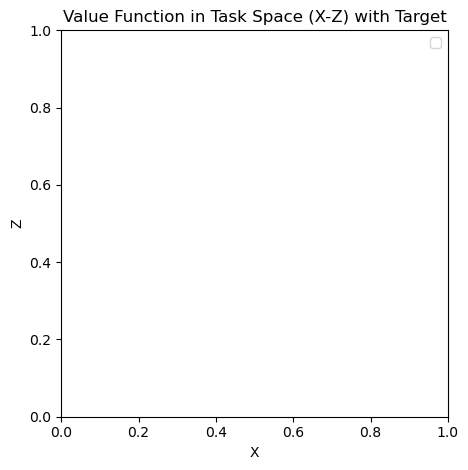

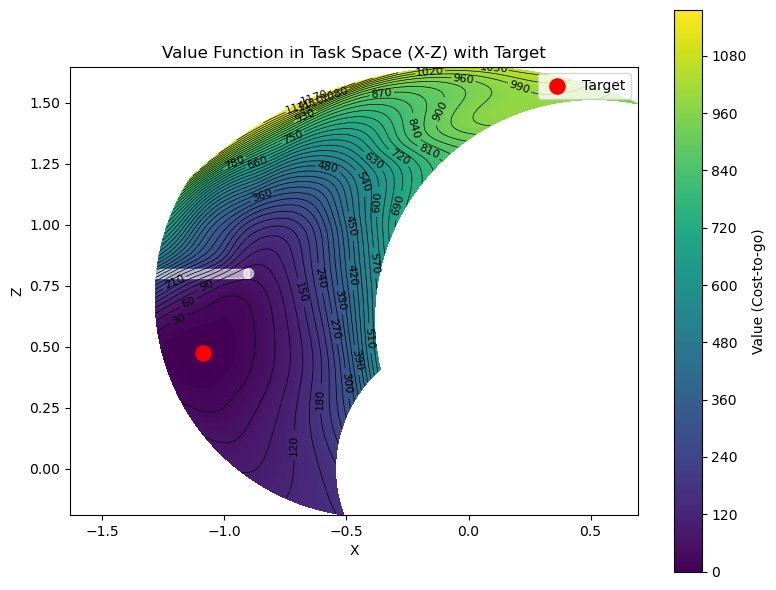

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from matplotlib.patches import Circle

# ============================================================
# 1. Set project root
# ============================================================
project_root = "/home/nsoh/Documents/mpc_MuJoCo"
os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from neural_network.models import TwoDofArmModel

# ============================================================
# 2. Load Model
# ============================================================
# weights_path = "value_iteration/output/2026-04-30_04-10-00_TwoDofArm_VI/loop_1/training/model_epoch_15.pt"
# weights_path = "value_iteration/output/2026-04-30_04-10-00_TwoDofArm_VI/loop_2/training/model_epoch_16.pt"
# weights_path = "value_iteration/output/2026-04-30_04-10-00_TwoDofArm_VI/loop_3/training/model_epoch_15.pt"
# weights_path = "value_iteration/output/2026-04-30_04-10-00_TwoDofArm_VI/loop_5/training/model_epoch_16.pt"
# weights_path = "value_iteration/output/2026-04-30_04-10-00_TwoDofArm_VI/loop_7/training/model_epoch_12.pt"
# weights_path = "value_iteration/output/2026-04-30_04-10-00_TwoDofArm_VI/loop_10/training/model_epoch_15.pt"
weights_path = "value_iteration/output/2026-04-30_04-10-00_TwoDofArm_VI/loop_16/training/model_epoch_14.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TwoDofArmModel(None)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

print("Model loaded on:", device)

# ============================================================
# 3. Target (from YAML)
# ============================================================
yref = np.array([
    -1.0880862442477446,
    0.0,
    0.47330858112333174
], dtype=np.float32)# ============================================================
# 13. Final formatting
# ============================================================
plt.xlabel("X")
plt.ylabel("Z")
plt.title("Value Function in Task Space (X-Z) with Target")
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 4. Arm Parameters
# ============================================================
l1 = 0.8
l2 = 0.9

def forward_kinematics(q1, q2):
    """Vectorized FK over arrays."""
    z = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    x = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)
    return x, z

# ============================================================
# 5. Capsule drawing
# ============================================================
def draw_capsule(ax, p1, p2, radius, color='white', alpha=0.6):
    p1 = np.array(p1)
    p2 = np.array(p2)

    d = p2 - p1
    length = np.linalg.norm(d)

    if length == 0:
        ax.add_patch(Circle(p1, radius, color=color, alpha=alpha))
        return

    d_unit = d / length
    perp = np.array([-d_unit[1], d_unit[0]])

    c1 = p1 + radius * perp
    c2 = p1 - radius * perp
    c3 = p2 - radius * perp
    c4 = p2 + radius * perp

    polygon = plt.Polygon([c1, c2, c3, c4], color=color, alpha=alpha)
    ax.add_patch(polygon)

    ax.add_patch(Circle(p1, radius, color=color, alpha=alpha))
    ax.add_patch(Circle(p2, radius, color=color, alpha=alpha))

# ============================================================
# 6. Create Grid in Joint Space
# ============================================================
grid_size = 100

q1_vals = np.linspace(-0.5, 0.7, grid_size)
q2_vals = np.linspace(-2.5, -0.5, grid_size)

Q1, Q2 = np.meshgrid(q1_vals, q2_vals, indexing='ij')

# ============================================================
# 7. Compute FK
# ============================================================
x_grid, z_grid = forward_kinematics(Q1, Q2)

# ============================================================
# 8. Target remap
# ============================================================
x_target = yref[0]
z_target = yref[2]

# ============================================================
# 9. Build NN input (10D)
# [q1, q2, qdot1, qdot2, x_ref, y_ref, z_ref, x, y, z]
# ============================================================
inputs = np.zeros((grid_size, grid_size, 10), dtype=np.float32)

inputs[:, :, 0] = Q1
inputs[:, :, 1] = Q2
inputs[:, :, 2] = 0.0
inputs[:, :, 3] = 0.0
inputs[:, :, 4] = x_target
inputs[:, :, 5] = 0.0
inputs[:, :, 6] = z_target
inputs[:, :, 7] = x_grid
inputs[:, :, 8] = 0.0
inputs[:, :, 9] = z_grid

# Flatten
inputs_flat = inputs.reshape(-1, 10)
inputs_tensor = torch.from_numpy(inputs_flat).to(device)

# ============================================================
# 10. Evaluate NN
# ============================================================
with torch.no_grad():
    values_flat = model(inputs_tensor).cpu().numpy().flatten()

cost_grid = values_flat.reshape(grid_size, grid_size)

# ============================================================
# 11. Plot
# ============================================================
plt.figure(figsize=(8, 6))

# Filled contour
contourf = plt.contourf(
    x_grid, z_grid, cost_grid,
    levels=200,
    cmap='viridis'
)

# Contour lines
contour_lines = plt.contour(
    x_grid, z_grid, cost_grid,
    levels=40,
    colors='black',
    linewidths=0.5
)

plt.clabel(contour_lines, inline=True, fontsize=8)
plt.colorbar(contourf, label="Value (Cost-to-go)")

# Target
plt.scatter(x_target, z_target,
            color='red', s=120, label="Target")

# ============================================================
# 12. Draw Capsule (EDIT THESE)
# ============================================================
ax = plt.gca()

# Example capsule in task space
p1 = [-1.5, 0.8]
p2 = [-0.9, 0.8]
radius = 0.02

draw_capsule(ax, p1, p2, radius)

# ============================================================
# 13. Final formatting
# ============================================================
plt.xlabel("X")
plt.ylabel("Z")
plt.title("Value Function in Task Space (X-Z) with Target")
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob
import re
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation

# ============================================================
# 1. Set project root
# ============================================================
project_root = "/home/nsoh/Documents/mpc_MuJoCo"
os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from neural_network.models import TwoDofArmModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2. Auto-discover checkpoints
# ============================================================
base_dir = "value_iteration/output/2026-04-30_04-10-00_TwoDofArm_VI"

def get_checkpoints(base_dir):
    checkpoints = []

    loop_dirs = sorted(
        glob.glob(os.path.join(base_dir, "loop_*")),
        key=lambda x: int(x.split("_")[-1])
    )

    for loop_dir in loop_dirs:
        loop_idx = int(loop_dir.split("_")[-1])
        training_dir = os.path.join(loop_dir, "training")
        pt_files = glob.glob(os.path.join(training_dir, "*.pt"))

        if not pt_files:
            continue

        def extract_epoch(path):
            match = re.search(r"model_epoch_(\d+)\.pt", path)
            return int(match.group(1)) if match else -1

        pt_files.sort(key=extract_epoch)
        best_file = pt_files[-1]

        checkpoints.append((loop_idx, best_file))

    return checkpoints

checkpoints = get_checkpoints(base_dir)

print("Found checkpoints:")
for loop_idx, path in checkpoints:
    print(f"Loop {loop_idx}: {path}")

# ============================================================
# 3. Target
# ============================================================
yref = np.array([
    -1.0880862442477446,
    0.0,
    0.47330858112333174
], dtype=np.float32)

x_target = yref[0]
z_target = yref[2]

# ============================================================
# 4. Arm FK
# ============================================================
l1, l2 = 0.8, 0.9

def forward_kinematics(q1, q2):
    z = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    x = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)
    return x, z

# ============================================================
# 5. Capsule
# ============================================================
def draw_capsule(ax, p1, p2, radius, color='white', alpha=0.6):
    p1 = np.array(p1)
    p2 = np.array(p2)

    d = p2 - p1
    length = np.linalg.norm(d)

    if length == 0:
        ax.add_patch(Circle(p1, radius, color=color, alpha=alpha))
        return

    d_unit = d / length
    perp = np.array([-d_unit[1], d_unit[0]])

    c1 = p1 + radius * perp
    c2 = p1 - radius * perp
    c3 = p2 - radius * perp
    c4 = p2 + radius * perp

    ax.add_patch(plt.Polygon([c1, c2, c3, c4], color=color, alpha=alpha))
    ax.add_patch(Circle(p1, radius, color=color, alpha=alpha))
    ax.add_patch(Circle(p2, radius, color=color, alpha=alpha))

# ============================================================
# 6. Grid (precompute once)
# ============================================================
grid_size = 100

q1_vals = np.linspace(-0.5, 0.7, grid_size)
q2_vals = np.linspace(-2.5, -0.5, grid_size)

Q1, Q2 = np.meshgrid(q1_vals, q2_vals, indexing='ij')
x_grid, z_grid = forward_kinematics(Q1, Q2)

# ============================================================
# 7. NN inputs (fixed)
# ============================================================
inputs = np.zeros((grid_size, grid_size, 10), dtype=np.float32)

inputs[:, :, 0] = Q1
inputs[:, :, 1] = Q2
inputs[:, :, 2] = 0.0
inputs[:, :, 3] = 0.0
inputs[:, :, 4] = x_target
inputs[:, :, 5] = 0.0
inputs[:, :, 6] = z_target
inputs[:, :, 7] = x_grid
inputs[:, :, 8] = 0.0
inputs[:, :, 9] = z_grid

inputs_tensor = torch.from_numpy(inputs.reshape(-1, 10)).to(device)

# ============================================================
# 8. Helpers
# ============================================================
def load_model(weights_path):
    model = TwoDofArmModel(None)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def compute_value(model):
    with torch.no_grad():
        values = model(inputs_tensor).cpu().numpy().flatten()
    return values.reshape(grid_size, grid_size)

# ============================================================
# 9. Precompute global color scale (IMPORTANT)
# ============================================================
print("Computing global min/max...")
all_values = []

for _, path in checkpoints:
    model = load_model(path)
    vals = compute_value(model)
    all_values.append(vals)

vmin = min(v.min() for v in all_values)
vmax = max(v.max() for v in all_values)

print("vmin:", vmin, "vmax:", vmax)

# ============================================================
# 10. Animation
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame):
    ax.clear()

    loop_idx, path = checkpoints[frame]
    print(f"Rendering loop {loop_idx}")

    model = load_model(path)
    cost_grid = compute_value(model)

    contourf = ax.contourf(
        x_grid, z_grid, cost_grid,
        levels=200,
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )

    contour_lines = ax.contour(
        x_grid, z_grid, cost_grid,
        levels=40,
        colors='black',
        linewidths=0.5
    )

    ax.clabel(contour_lines, inline=True, fontsize=7)

    ax.scatter(x_target, z_target, color='red', s=120, label="Target")
    draw_capsule(ax, [-1.5, 0.8], [-0.9, 0.8], 0.02)

    ax.set_title(f"Loop {loop_idx}")
    ax.set_xlabel("X")
    ax.set_ylabel("Z")
    ax.set_aspect('equal', adjustable='box')
    ax.legend()

    return []

anim = FuncAnimation(fig, update, frames=len(checkpoints), interval=800)

# plt.show()

# ============================================================
# Optional save
# ============================================================
anim.save("value_evolution.mp4", fps=1)
# anim.save("value_evolution.gif", writer='pillow', fps=2)

In [2]:
import os
import sys

# ---- 1. Set the project root folder ----
# Adjust this to the path of your main project folder
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"  # e.g., "/Users/you/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Evaluate the NN at the set point.
import torch
import numpy as np
from neural_network.models import TwoDofArmModel

# -----------------------------
# Load model
# -----------------------------
weights_path = "value_iteration/output/2026-02-25_21-18-22_TwoDofArm_VI/loop_38/training/model_epoch_15.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TwoDofArmModel(None)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

# -----------------------------
# Define inputs
# -----------------------------

# Cartesian target
yref = np.array([
    -0.5522350408628973,
    0.0,
    1.2858399579259427
], dtype=np.float32)

# Joint reference
yref_q = np.array([
    0.24,
    -1.21,
    0.0,
    0.0
], dtype=np.float32)

# Concatenate
input_vec = np.concatenate([yref_q, yref])   # shape (7,)

# Convert to torch tensor with batch dimension
input_tensor = torch.tensor(input_vec, dtype=torch.float32).unsqueeze(0).to(device)

# -----------------------------
# Evaluate model
# -----------------------------

with torch.no_grad():
    output = model(input_tensor)

print("Input:", input_vec)
print("Model output:", output.cpu().numpy())

Current working directory: /Users/nicodemussoh/Documents/mpc_MuJoCo


Input: [ 0.24       -1.21        0.          0.         -0.55223507  0.
  1.2858399 ]
Model output: [[0.06035744]]


In [12]:
import os
import sys

# ---- 1. Set the project root folder ----
# Adjust this to the path of your main project folder
project_root = "/home/nsoh/Documents/mpc_MuJoCo"  # e.g., "/Users/you/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
from data_collection.data_utils import load_npz

data_25 = load_npz("data/2026-04-29_11-53-05_TwoDofArm_MPC_25/2026-04-29_11-53-05_logs.npz")["default"]
data_100 = load_npz("data/2026-04-29_11-55-17_TwoDofArm_NN_e1_H100/2026-04-29_11-55-17_logs.npz")["default"]

Current working directory: /home/nsoh/Documents/mpc_MuJoCo

Loaded file: data/2026-04-29_11-53-05_TwoDofArm_MPC_25/2026-04-29_11-53-05_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj', 'yref_q', 'xyzpos', 'GT_xyz_traj']

Loaded file: data/2026-04-29_11-55-17_TwoDofArm_NN_e1_H100/2026-04-29_11-55-17_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj', 'yref_q', 'xyzpos', 'GT_xyz_traj']


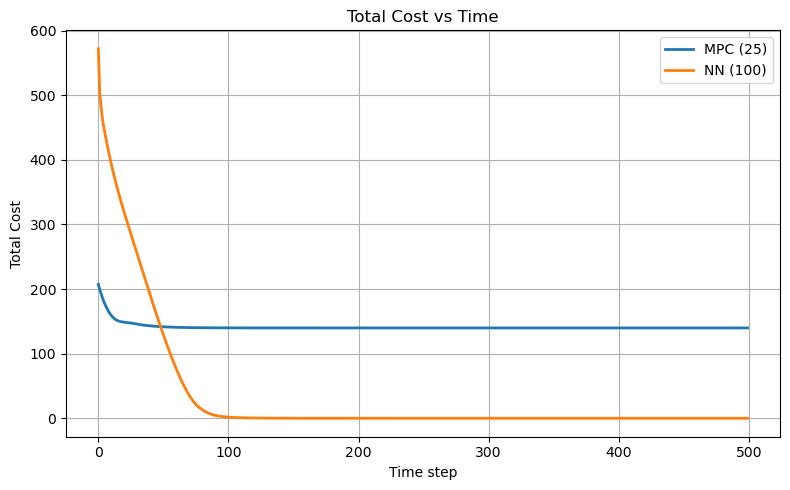

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Extract cost
cost_25 = data_25["total_cost"]
cost_100 = data_100["total_cost"]

# Create time axes (assuming constant timestep)
t_25 = np.arange(len(cost_25))
t_100 = np.arange(len(cost_100))

# Plot
plt.figure(figsize=(8, 5))

plt.plot(t_25, cost_25, label="MPC (25)", linewidth=2)
plt.plot(t_100, cost_100, label="NN (100)", linewidth=2)

plt.xlabel("Time step")
plt.ylabel("Total Cost")
plt.title("Total Cost vs Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

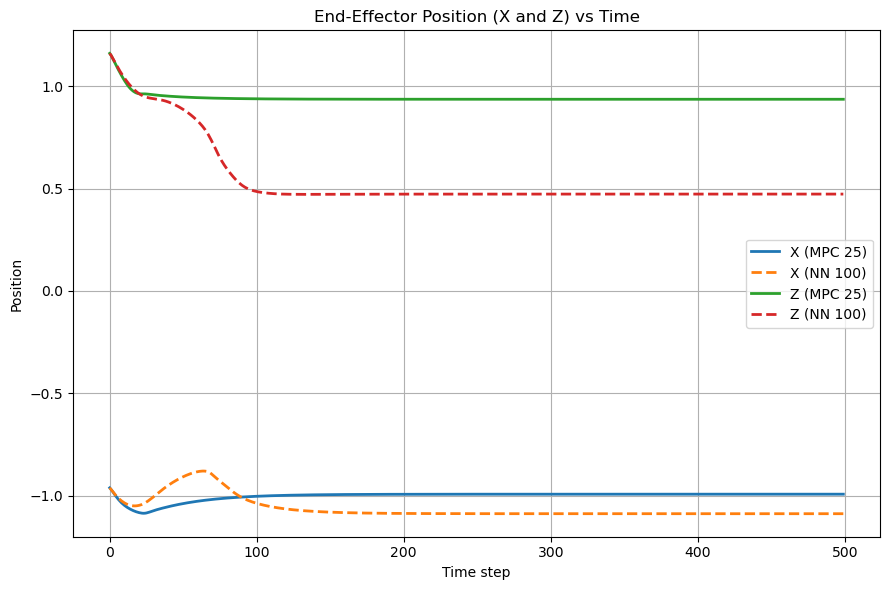

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Extract positions
pos_25 = data_25["xyzpos"]
pos_100 = data_100["xyzpos"]

# Ensure proper shape (T, 3)
pos_25 = np.asarray(pos_25)
pos_100 = np.asarray(pos_100)

# Split components
x_25 = pos_25[:, 0]
z_25 = pos_25[:, 2]

x_100 = pos_100[:, 0]
z_100 = pos_100[:, 2]

# Time axes
t_25 = np.arange(len(x_25))
t_100 = np.arange(len(x_100))

# Plot
plt.figure(figsize=(9, 6))

# X plots
plt.plot(t_25, x_25, label="X (MPC 25)", linewidth=2)
plt.plot(t_100, x_100, '--', label="X (NN 100)", linewidth=2)

# Z plots
plt.plot(t_25, z_25, label="Z (MPC 25)", linewidth=2)
plt.plot(t_100, z_100, '--', label="Z (NN 100)", linewidth=2)

plt.xlabel("Time step")
plt.ylabel("Position")
plt.title("End-Effector Position (X and Z) vs Time")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

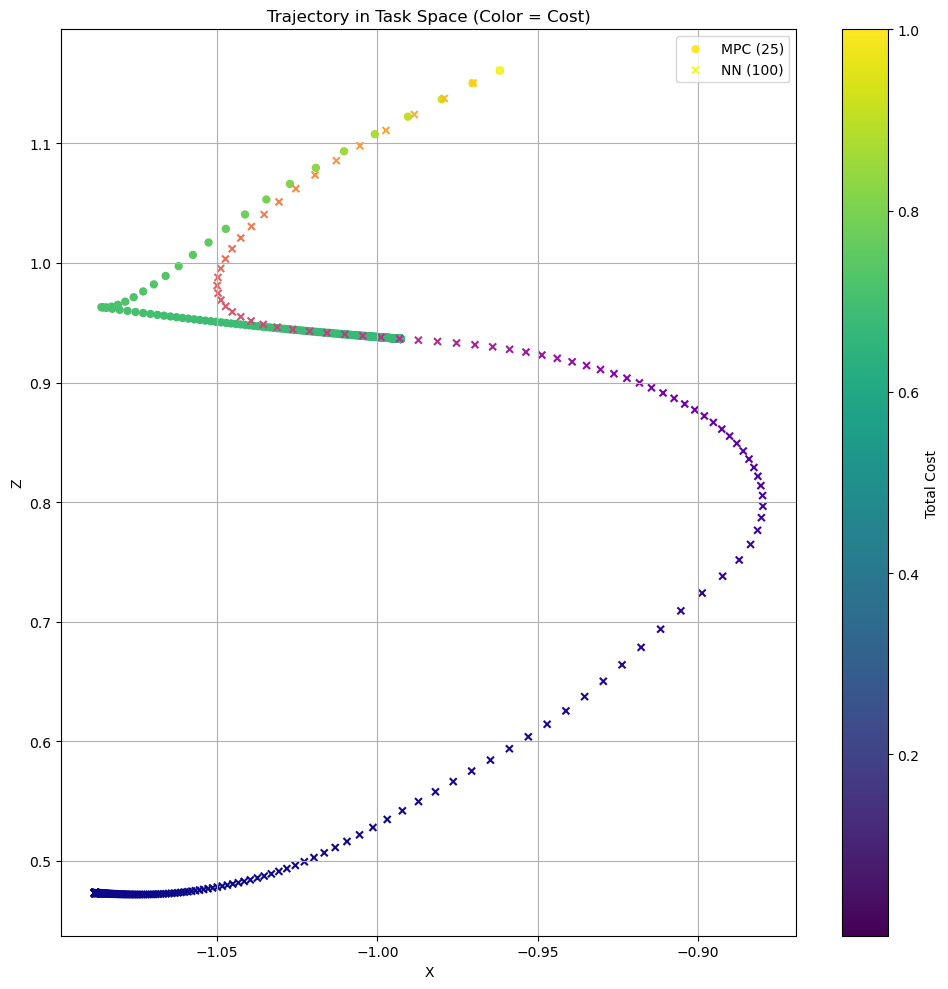

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data
pos_25 = np.asarray(data_25["xyzpos"])
pos_100 = np.asarray(data_100["xyzpos"])

cost_25 = np.asarray(data_25["total_cost"]).squeeze()/cost_25.max()
cost_100 = np.asarray(data_100["total_cost"]).squeeze()/cost_100.max()

# Split coordinates
x_25, z_25 = pos_25[:, 0], pos_25[:, 2]
x_100, z_100 = pos_100[:, 0], pos_100[:, 2]

# Normalize cost for better color scaling (optional but recommended)
all_costs = np.concatenate([cost_25, cost_100])
vmin, vmax = np.min(all_costs), np.max(all_costs)

plt.figure(figsize=(10, 10))

# MPC
sc1 = plt.scatter(
    x_25, z_25,
    c=cost_25,
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    s=25,
    label="MPC (25)"
)

# NN
sc2 = plt.scatter(
    x_100, z_100,
    c=cost_100,
    cmap='plasma',
    vmin=vmin, vmax=vmax,
    s=25,
    marker='x',
    label="NN (100)"
)

# Colorbar (shared scale)
cbar = plt.colorbar(sc1)
cbar.set_label("Total Cost")

plt.xlabel("X")
plt.ylabel("Z")
plt.title("Trajectory in Task Space (Color = Cost)")
plt.legend()
plt.grid(True)
# plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

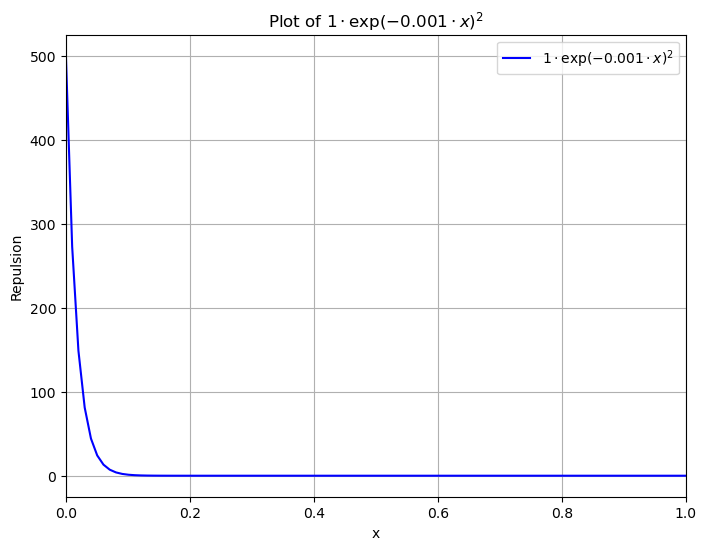

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def repulsion(x):
    return 500 * np.exp(-30 * x)**2

# Generate x values
x_values = np.linspace(0, 1, 100)

# Compute the repulsion values
y_values = repulsion(x_values)

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label=r'$1 \cdot \exp(-0.001 \cdot x)^2$', color='b')
plt.title('Plot of $1 \cdot \exp(-0.001 \cdot x)^2$')
plt.xlabel('x')
# plt.ylim(0, 1000)
plt.xlim(0, 1)
plt.ylabel('Repulsion')
plt.grid(True)
plt.legend()
plt.show()